## 1. Persiapan Lingkungan

In [1]:

# Instalasi library yang diperlukan
!pip install -q pyarrow psutil pyspark==3.5.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [2]:

import os
import time
import psutil
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F

# Direktori kerja
DIR_KERJA = "/content/bigdata_q1"
os.makedirs(DIR_KERJA, exist_ok=True)

# Proses untuk pengukuran memori
proses = psutil.Process(os.getpid())

print("Direktori kerja:", DIR_KERJA)
print("Python:", __import__("sys").version.split()[0])
print("CPU logical:", os.cpu_count())
print("RAM total (GB):", round(psutil.virtual_memory().total / 1024**3, 2))


Direktori kerja: /content/bigdata_q1
Python: 3.13.15
CPU logical: 2
RAM total (GB): 12.67


## 2. Download Dataset Januari dan Juli 2023

In [3]:

URL_JAN = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_JULI = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"

PATH_JAN = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
PATH_JULI = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH_JAN):
    !wget -q -O "{PATH_JAN}" "{URL_JAN}"

if not os.path.exists(PATH_JULI):
    !wget -q -O "{PATH_JULI}" "{URL_JULI}"

print("Januari tersedia:", os.path.exists(PATH_JAN))
print("Juli tersedia:", os.path.exists(PATH_JULI))
print("Ukuran Januari (MB):", round(os.path.getsize(PATH_JAN) / 1024**2, 2))
print("Ukuran Juli (MB):", round(os.path.getsize(PATH_JULI) / 1024**2, 2))


Januari tersedia: True
Juli tersedia: True
Ukuran Januari (MB): 45.46
Ukuran Juli (MB): 46.12


## 3. Q1 – Memeriksa Metadata dan Kolom Dataset Baru

In [4]:

import pyarrow.parquet as pq

metadata_juli = pq.ParquetFile(PATH_JULI)

print("Jumlah baris Juli:", metadata_juli.metadata.num_rows)
print("Jumlah kolom Juli:", metadata_juli.metadata.num_columns)
print("\nNama kolom:")
print(metadata_juli.schema.names)


Jumlah baris Juli: 2907108
Jumlah kolom Juli: 19

Nama kolom:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


### Membaca Kolom yang Dibutuhkan

In [5]:

COLS = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

def baca_data(path, nama):
    rss_awal = proses.memory_info().rss / 1024**2
    mulai = time.perf_counter()

    df = pd.read_parquet(path, columns=COLS)

    waktu = time.perf_counter() - mulai
    rss_akhir = proses.memory_info().rss / 1024**2

    print(f"{nama}: {len(df):,} baris")
    print(f"Waktu baca: {waktu:.2f} detik")
    print(f"RSS delta: {rss_akhir - rss_awal:.2f} MB")
    return df, waktu, rss_akhir - rss_awal

jan, waktu_baca_jan, rss_baca_jan = baca_data(PATH_JAN, "Januari")
juli, waktu_baca_juli, rss_baca_juli = baca_data(PATH_JULI, "Juli")


Januari: 3,066,766 baris
Waktu baca: 0.68 detik
RSS delta: 223.25 MB
Juli: 2,907,108 baris
Waktu baca: 0.44 detik
RSS delta: 168.59 MB


## 4. Q1 – Pembersihan Data (J-6)

In [6]:

def bersihkan(df, nama):
    mulai = time.perf_counter()

    df = df.copy()
    df["durasi_menit"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    hasil = df[
        (df["trip_distance"] > 0) &
        (df["trip_distance"] < 100) &
        (df["durasi_menit"] >= 1) &
        (df["durasi_menit"] <= 180) &
        (df["total_amount"] > 0)
    ].copy()

    waktu = time.perf_counter() - mulai

    print(f"\n{nama}")
    print("Sebelum :", f"{len(df):,}")
    print("Sesudah :", f"{len(hasil):,}")
    print("Dihapus :", f"{len(df) - len(hasil):,}")
    print("Persentase dihapus:", round((len(df)-len(hasil))/len(df)*100, 2), "%")
    print("Waktu cleaning:", round(waktu, 2), "detik")

    return hasil, waktu

bersih_jan, waktu_clean_jan = bersihkan(jan, "Januari")
bersih_juli, waktu_clean_juli = bersihkan(juli, "Juli")



Januari
Sebelum : 3,066,766
Sesudah : 2,986,911
Dihapus : 79,855
Persentase dihapus: 2.6 %
Waktu cleaning: 0.77 detik

Juli
Sebelum : 2,907,108
Sesudah : 2,817,657
Dihapus : 89,451
Persentase dihapus: 3.08 %
Waktu cleaning: 0.65 detik


## 5. Q1 – Agregasi per Jam (J-9)

In [7]:

def agregasi_per_jam(df):
    data = df.copy()
    data["jam"] = data["tpep_pickup_datetime"].dt.hour

    hasil = (
        data.groupby("jam")
        .agg(
            jumlah_perjalanan=("total_amount", "size"),
            rata_jarak=("trip_distance", "mean"),
            rata_durasi=("durasi_menit", "mean"),
            rata_tarif=("total_amount", "mean")
        )
        .round(2)
        .reset_index()
    )
    return hasil

agregasi_jan = agregasi_per_jam(bersih_jan)
agregasi_juli = agregasi_per_jam(bersih_juli)

print("Agregasi Januari:")
display(agregasi_jan)

print("Agregasi Juli:")
display(agregasi_juli)


Agregasi Januari:


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif
0,0,82289,4.04,13.57,28.86
1,1,57766,3.53,12.63,26.45
2,2,40445,3.28,12.07,25.06
3,3,26146,3.58,12.15,26.26
4,4,16618,4.79,13.52,31.72
5,5,16940,6.03,14.70,36.75
6,6,42300,4.80,14.49,30.63
7,7,84569,3.69,14.42,26.89
8,8,114064,3.08,14.33,25.21
9,9,127988,3.09,14.23,25.51


Agregasi Juli:


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif
0,0,85987,4.45,14.82,31.05
1,1,59980,4.04,13.52,28.64
2,2,40812,3.79,12.82,27.08
3,3,26000,4.02,12.83,27.92
4,4,16637,5.60,14.62,34.92
5,5,16913,6.67,15.65,39.74
6,6,38422,5.11,14.51,32.13
7,7,69358,4.10,14.57,28.60
8,8,103647,3.53,15.30,27.34
9,9,118788,3.40,15.68,27.28


## 6. Q1 – Simpan Hasil

In [8]:

agregasi_jan.to_csv(os.path.join(DIR_KERJA, "agregasi_per_jam_januari.csv"), index=False)
agregasi_jan.to_parquet(os.path.join(DIR_KERJA, "agregasi_per_jam_januari.parquet"), index=False)

agregasi_juli.to_csv(os.path.join(DIR_KERJA, "agregasi_per_jam_juli.csv"), index=False)
agregasi_juli.to_parquet(os.path.join(DIR_KERJA, "agregasi_per_jam_juli.parquet"), index=False)

print("File hasil Q1 berhasil disimpan.")


File hasil Q1 berhasil disimpan.


## 7. Q2 – Perbandingan Pola Januari dan Juli

In [9]:

perbandingan_bulan = agregasi_jan[
    ["jam", "jumlah_perjalanan"]
].merge(
    agregasi_juli[
        ["jam", "jumlah_perjalanan"]
    ],
    on="jam",
    suffixes=("_januari", "_juli")
)

display(perbandingan_bulan)

jam_tertinggi_jan = agregasi_jan.loc[
    agregasi_jan["jumlah_perjalanan"].idxmax()
]
jam_terendah_jan = agregasi_jan.loc[
    agregasi_jan["jumlah_perjalanan"].idxmin()
]

jam_tertinggi_juli = agregasi_juli.loc[
    agregasi_juli["jumlah_perjalanan"].idxmax()
]
jam_terendah_juli = agregasi_juli.loc[
    agregasi_juli["jumlah_perjalanan"].idxmin()
]

print("\nJanuari - tertinggi:",
      int(jam_tertinggi_jan["jam"]),
      "dengan", f"{int(jam_tertinggi_jan['jumlah_perjalanan']):,}", "perjalanan")
print("Januari - terendah:",
      int(jam_terendah_jan["jam"]),
      "dengan", f"{int(jam_terendah_jan['jumlah_perjalanan']):,}", "perjalanan")

print("\nJuli - tertinggi:",
      int(jam_tertinggi_juli["jam"]),
      "dengan", f"{int(jam_tertinggi_juli['jumlah_perjalanan']):,}", "perjalanan")
print("Juli - terendah:",
      int(jam_terendah_juli["jam"]),
      "dengan", f"{int(jam_terendah_juli['jumlah_perjalanan']):,}", "perjalanan")


,jam,jumlah_perjalanan_januari,jumlah_perjalanan_juli
0,0,82289,85987
1,1,57766,59980
2,2,40445,40812
3,3,26146,26000
4,4,16618,16637
5,5,16940,16913
6,6,42300,38422
7,7,84569,69358
8,8,114064,103647
9,9,127988,118788



Januari - tertinggi: 18 dengan 210,858 perjalanan
Januari - terendah: 4 dengan 16,618 perjalanan

Juli - tertinggi: 18 dengan 195,988 perjalanan
Juli - terendah: 4 dengan 16,637 perjalanan


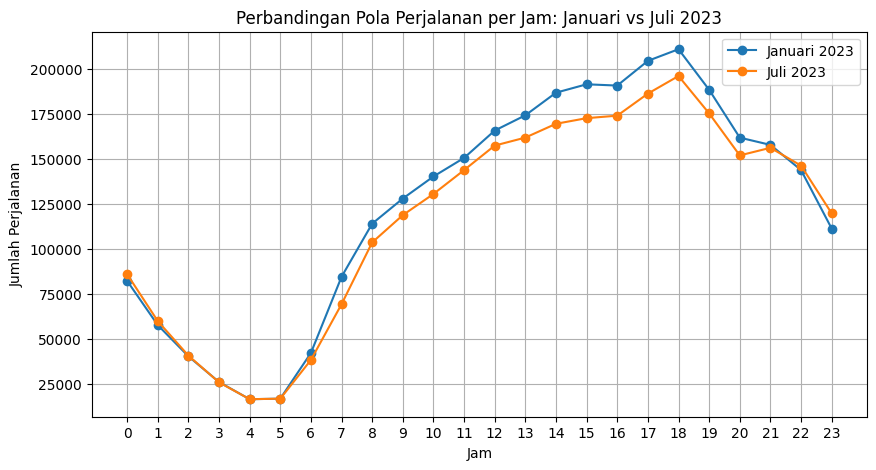

In [10]:

plt.figure(figsize=(10, 5))

plt.plot(
    perbandingan_bulan["jam"],
    perbandingan_bulan["jumlah_perjalanan_januari"],
    marker="o",
    label="Januari 2023"
)

plt.plot(
    perbandingan_bulan["jam"],
    perbandingan_bulan["jumlah_perjalanan_juli"],
    marker="o",
    label="Juli 2023"
)

plt.xlabel("Jam")
plt.ylabel("Jumlah Perjalanan")
plt.title("Perbandingan Pola Perjalanan per Jam: Januari vs Juli 2023")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(DIR_KERJA, "perbandingan_januari_juli.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


## 8. Q3 – Pengukuran Kinerja

In [11]:

# Pengukuran sederhana untuk proses utama pada dataset Juli
pengukuran = []

def ukur_baca_juli():
    rss_awal = proses.memory_info().rss / 1024**2
    mulai = time.perf_counter()
    _ = pd.read_parquet(PATH_JULI, columns=COLS)
    waktu = time.perf_counter() - mulai
    rss_akhir = proses.memory_info().rss / 1024**2
    return waktu, rss_akhir - rss_awal

waktu, rss = ukur_baca_juli()
pengukuran.append(["Baca kolom terpilih Juli", waktu, rss])

mulai = time.perf_counter()
_ = bersihkan(juli, "Pengukuran cleaning Juli")
waktu_clean = time.perf_counter() - mulai
pengukuran.append(["Cleaning Juli", waktu_clean, None])

mulai = time.perf_counter()
_ = agregasi_per_jam(bersih_juli)
waktu_agg = time.perf_counter() - mulai
pengukuran.append(["Agregasi per jam Juli", waktu_agg, None])

pengukuran_kinerja = pd.DataFrame(
    pengukuran,
    columns=["langkah", "waktu_detik", "rss_delta_mb"]
)

display(pengukuran_kinerja)

pengukuran_kinerja.to_csv(
    os.path.join(DIR_KERJA, "pengukuran_kinerja.csv"),
    index=False
)



Pengukuran cleaning Juli
Sebelum : 2,907,108
Sesudah : 2,817,657
Dihapus : 89,451
Persentase dihapus: 3.08 %
Waktu cleaning: 0.82 detik


,langkah,waktu_detik,rss_delta_mb
0,Baca kolom terpilih Juli,0.811501,220.613281
1,Cleaning Juli,0.819902,NaN
2,Agregasi per jam Juli,0.569195,NaN


In [12]:

print("File output:")
for nama in sorted(os.listdir(DIR_KERJA)):
    print("-", nama)


File output:
- agregasi_per_jam_januari.csv
- agregasi_per_jam_januari.parquet
- agregasi_per_jam_juli.csv
- agregasi_per_jam_juli.parquet
- pengukuran_kinerja.csv
- perbandingan_januari_juli.png
- yellow_tripdata_2023-01.parquet
- yellow_tripdata_2023-07.parquet
